Dataset is taken from kaggle.
link: "[Dataset link](https://www.kaggle.com/datasets/nikhilroxtomar/brain-tumor-segmentation?resource=download)"

In [1]:
%pip install numpy opencv-python scikit-image scikit-learn matplotlib pandas tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt

from skimage.filters import threshold_otsu, threshold_sauvola
from skimage.morphology import disk, closing, opening
from skimage.measure import label

from sklearn.metrics import jaccard_score


In [5]:
IM_DIR = "C:\\Users\\bahub\\Documents\\MRI_TUMOUR_SEGMENTATION\\Project-1\\Brain-mri\\images"
MASK_DIR = "C:\\Users\\bahub\\Documents\\MRI_TUMOUR_SEGMENTATION\\Project-1\\Brain-mri\\masks"

# Sauvola parameters
SAUVOLA_WINDOW = 51
SAUVOLA_K = 0.2

# Postprocessing
MIN_OBJ_SIZE = 100
MORPH_RADIUS = 3

print("Images:", len(os.listdir(IM_DIR)))
print("Masks:", len(os.listdir(MASK_DIR)))


Images: 3064
Masks: 3064


In [6]:
def dice_coef(y_true, y_pred):
    y_true = y_true.flatten().astype(bool)
    y_pred = y_pred.flatten().astype(bool)

    if y_true.sum() + y_pred.sum() == 0:
        return 1.0

    inter = np.logical_and(y_true, y_pred).sum()
    return 2 * inter / (y_true.sum() + y_pred.sum())


def jaccard_idx(y_true, y_pred):
    y_true = y_true.flatten().astype(bool)
    y_pred = y_pred.flatten().astype(bool)

    if y_true.sum() + y_pred.sum() == 0:
        return 1.0

    return jaccard_score(y_true, y_pred)


In [7]:
def read_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # CLAHE contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))
    img = clahe.apply(img)

    # Smooth noise
    img = cv2.GaussianBlur(img, (5,5), 0)

    return img


def postprocess_mask(mask):
    se = disk(4)
    mask = closing(mask, se)

    # keep only largest connected component
    lab = label(mask)
    if lab.max() == 0:
        return mask

    sizes = [(lab==i).sum() for i in range(1, lab.max()+1)]
    largest = np.argmax(sizes) + 1
    mask = (lab == largest).astype(np.uint8)

    return mask


In [8]:
def get_brain_roi(img):
    t = threshold_otsu(img)
    mask = (img > t*0.6).astype(np.uint8)

    mask = cv2.medianBlur(mask*255, 7)
    mask = (mask > 0).astype(np.uint8)

    lab = label(mask)
    if lab.max() == 0:
        
        return mask

    sizes = [(lab==i).sum() for i in range(1, lab.max()+1)]
    largest = np.argmax(sizes) + 1
    mask = (lab == largest).astype(np.uint8)

    return mask


In [9]:
def otsu_seg(img):
    roi = get_brain_roi(img)
    masked = img * roi

    t = threshold_otsu(masked[roi>0])
    mask = (masked > t).astype(np.uint8)

    mask = mask * roi
    return postprocess_mask(mask)


def sauvola_seg(img):
    thr = threshold_sauvola(
        img,
        window_size=61,
        k=0.25
    )

    mask = (img > thr).astype(np.uint8)
    mask = mask * get_brain_roi(img)

    return postprocess_mask(mask)


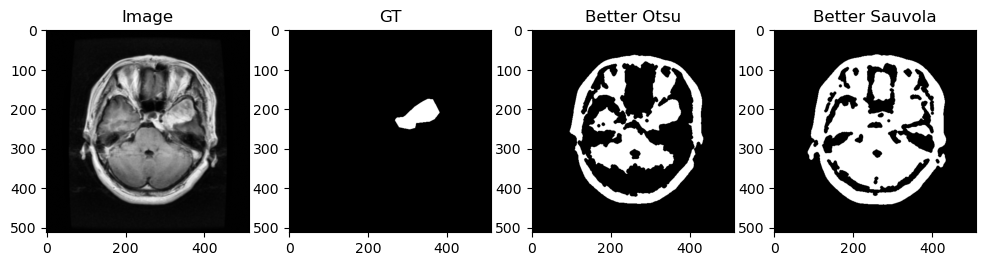

In [10]:
sample_path = glob.glob(IM_DIR + "/*")[0]
name = os.path.basename(sample_path)

img = read_gray(sample_path)
gt = cv2.imread(os.path.join(MASK_DIR, name), 0)
gt = (gt > 127).astype(np.uint8)

o = otsu_seg(img)
s = sauvola_seg(img)

plt.figure(figsize=(12,4))
plt.subplot(1,4,1); plt.title("Image"); plt.imshow(img, cmap="gray")
plt.subplot(1,4,2); plt.title("GT"); plt.imshow(gt, cmap="gray")
plt.subplot(1,4,3); plt.title("Better Otsu"); plt.imshow(o, cmap="gray")
plt.subplot(1,4,4); plt.title("Better Sauvola"); plt.imshow(s, cmap="gray")
plt.show()


In [11]:
image_paths = sorted(glob.glob(IM_DIR + "/*"))

records = []

for path in tqdm(image_paths):
    name = os.path.basename(path)

    mask_path = os.path.join(MASK_DIR, name)
    if not os.path.exists(mask_path):
        continue

    img = read_gray(path)
    gt = cv2.imread(mask_path, 0)
    gt = (gt > 127).astype(np.uint8)

    pred_o = otsu_seg(img)
    pred_s = sauvola_seg(img)

    d_o = dice_coef(gt, pred_o)
    j_o = jaccard_idx(gt, pred_o)

    d_s = dice_coef(gt, pred_s)
    j_s = jaccard_idx(gt, pred_s)

    records.append([name, d_o, j_o, d_s, j_s])


  0%|          | 0/3064 [00:00<?, ?it/s]

100%|██████████| 3064/3064 [14:08<00:00,  3.61it/s]


In [12]:
df = pd.DataFrame(records, columns=[
    "file",
    "dice_otsu",
    "jaccard_otsu",
    "dice_sauvola",
    "jaccard_sauvola"
])

df.head()


,file,dice_otsu,jaccard_otsu,dice_sauvola,jaccard_sauvola
0,1.png,0.158964,0.086345,0.108819,0.057540
1,10.png,0.000000,0.000000,0.081639,0.042557
2,100.png,0.114588,0.060776,0.053288,0.027373
3,1000.png,0.000000,0.000000,0.027471,0.013927
4,1001.png,0.000000,0.000000,0.029709,0.015078


In [13]:
means = df.mean(numeric_only=True)
means


dice_otsu          0.033520
jaccard_otsu       0.018309
dice_sauvola       0.062202
jaccard_sauvola    0.032871
dtype: float64